# Division 1 Wrestling Exporatory Data Analysis

This exploratory data analysis examines NCAA Division I wrestling match data from the 2013–2014 season through the present. The dataset includes  unique matches between individual wrestlers, with each bout recorded once regardless of whether the wrestler appeared as the primary or opponent.

The goal of this analysis is to uncover patterns and trends across seasons, teams, weight classes, and individual wrestlers. Key areas of focus include win distributions, bonus point frequency, team and wrestler performance over time, and the evolving dynamics of collegiate wrestling.

Insights from this EDA will inform feature engineering and modeling strategies for downstream predictive tasks, such as forecasting match outcomes or identifying performance trends.

In [140]:
# Importing packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [141]:
# Importing data
matches = pd.read_csv('../data/clean/d1_results_unique.csv')

In [142]:
# Quick view of dataset columns
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263422 entries, 0 to 263421
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   season           263422 non-null  object
 1   date             263422 non-null  object
 2   event            263422 non-null  object
 3   weight_class     263422 non-null  int64 
 4   wrestler         263422 non-null  object
 5   wrestler_id      263422 non-null  int64 
 6   wrestler_school  263422 non-null  object
 7   opponent         263422 non-null  object
 8   opponent_id      263422 non-null  int64 
 9   opponent_school  263422 non-null  object
 10  result           263422 non-null  object
 11  result_type      263422 non-null  object
 12  score            263422 non-null  object
 13  match_duration   263422 non-null  object
dtypes: int64(3), object(11)
memory usage: 28.1+ MB


In [143]:
# Helper function to title, label the axes, and despine the graphs
def label_and_despine(title = '', xlabel = '', ylabel = '', despine = True, subplots = False):
    if despine:
        sns.despine()
    if subplots:
        fig.suptitle(title)
    else:
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)

# Overview of Time Period

Since all of the data has already been cleaned and deduplicated, I will jump right into the analysis, starting with a higher level overview of trends across the entire time period.

First off I want to look at the different result types, and how frequently they appear in the dataset.

In [144]:
# Getting the counts for each result type
counts = {}

for result in matches['result_type'].unique():
    counts[result] = (matches['result_type'] == result).sum()

for result, count in counts.items():
    print(f'{count} matches resulted in {result}')

7252 matches resulted in MFOR
124518 matches resulted in DEC
43509 matches resulted in MD
988 matches resulted in TB-2
48476 matches resulted in FALL
116 matches resulted in DEF
23979 matches resulted in TF5
8537 matches resulted in SV-1
253 matches resulted in DQ
318 matches resulted in SV-2
1431 matches resulted in TB-1
2142 matches resulted in INJ
76 matches resulted in TB-3
57 matches resulted in SV-3
1347 matches resulted in TF4
12 matches resulted in FOR
411 matches resulted in CMFF


It definitely seems like some of the categories should be combined to make overall analysis easier, but I'll make a bar graph to double check

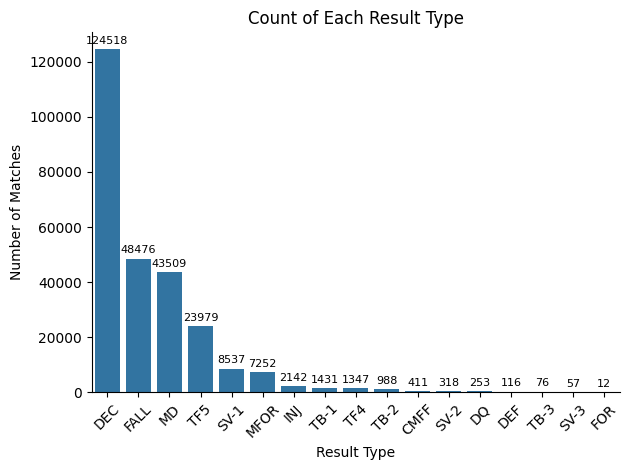

In [145]:
# Bar chart of count of each result
g = sns.countplot(data=matches, x='result_type', order=matches['result_type'].value_counts().index)

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 2000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=8
    )

label_and_despine('Count of Each Result Type', 'Result Type', 'Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()

From the graph, it is pretty easy to tell that there are a bunch of result types that are such small portions of the overall data that there isn't much reason to graph them as separate columns.

For that reason, I'm going to combine some of the columns to make the graph easier to read. 

The new categories will be: 
- OT: `SV-1`, `SV-2`, `SV-3`, `TB-1`, `TB-2`, `TB-3`
- FF: `FOR`, `CMFF`, `MFOR`
- TF: `TF5`, `TF4`
- Other: `INJ`, `DQ`, `DEF`

With `DEC`, `FALL`, and `MD` remaining the same

In [146]:
# Creating a new df and modifying the result_type to create new categories
recategorized = matches.copy(deep=True)
recategorized.loc[recategorized['result_type'].isin(['SV-1', 'SV-2', 'SV-3', 'TB-1', 'TB-2', 'TB-3']), 'result_type'] = 'OT'
recategorized.loc[recategorized['result_type'].isin(['FOR', 'CMFF', 'MFOR']), 'result_type'] = 'FF'
recategorized.loc[recategorized['result_type'].isin(['TF5', 'TF4']), 'result_type'] = 'TF'
recategorized.loc[recategorized['result_type'].isin(['INJ', 'DQ', 'DEF']), 'result_type'] = 'Other'

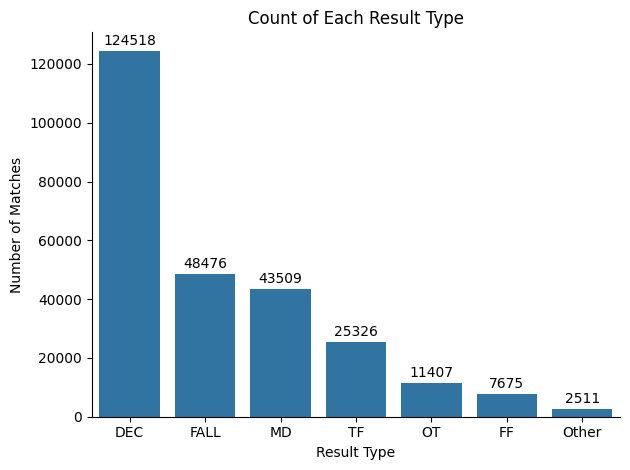

In [147]:
# Count bar chart of recategorized result types
g = sns.countplot(data=recategorized, x='result_type', order=recategorized['result_type'].value_counts().index)

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 2000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=10
    )

label_and_despine('Count of Each Result Type', 'Result Type', 'Number of Matches')
plt.tight_layout()

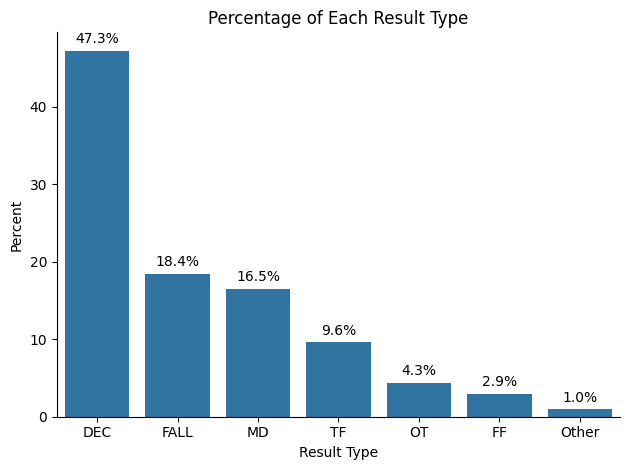

In [148]:
# Percentage bar chart of recategorized result types
g = sns.countplot(data=recategorized, x='result_type', order=recategorized['result_type'].value_counts().index, stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )
    
label_and_despine('Percentage of Each Result Type', 'Result Type', 'Percent')
plt.tight_layout()

This seems like a pretty clear graph, but it doesn't account for the fact that falls can take place in overtime as well.

In [149]:
# Finding how many falls occurred in overtime (indicated by a match_duration of more than seven minutes)
len(recategorized[(recategorized['result_type'] == 'FALL') & (recategorized['match_duration'] > '7:00')])

298

Only 298 falls in overtime is a very small relative number so it would have minimal impact on the graphes above.

To truly rectify the issue though, I'll plot the number of matches that end in regulation versus the number that end in overtime.

In [150]:
# Creating new column to mark matches concluded in overtime
recategorized.loc[:, 'in_overtime'] = recategorized['match_duration'] > '7:00'

C:\Users\kikip\AppData\Local\Temp\ipykernel_57848\2658474909.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Regulation', 'Overtime'])


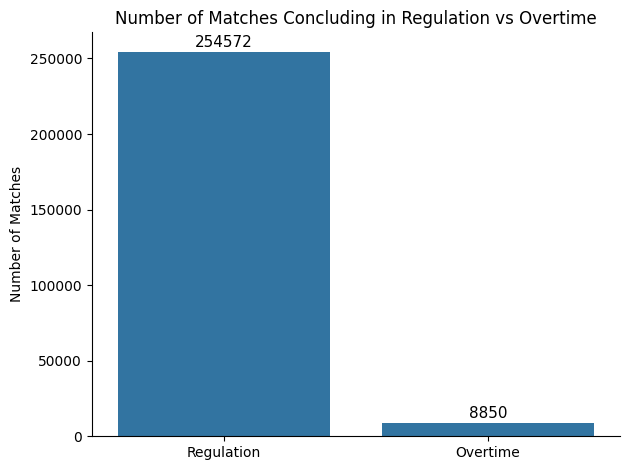

In [151]:
# Count of regulation versus overtime matches
g = sns.countplot(data=recategorized, x='in_overtime')

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 3000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=11
    )

g.set_xticklabels(['Regulation', 'Overtime'])
label_and_despine('Number of Matches Concluding in Regulation vs Overtime', ylabel='Number of Matches')
plt.tight_layout()

C:\Users\kikip\AppData\Local\Temp\ipykernel_57848\376861818.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Regulation', 'Overtime'])


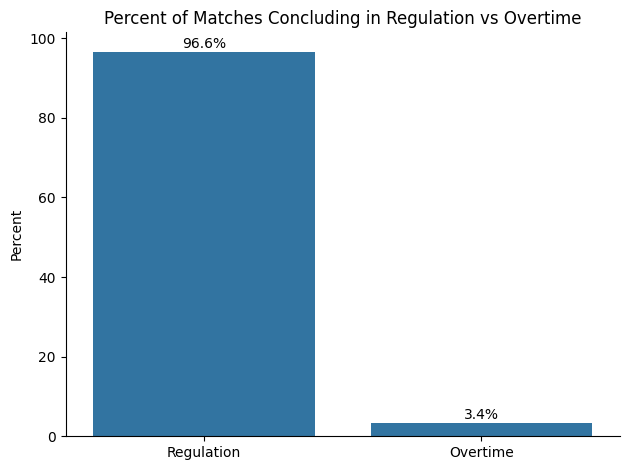

In [152]:
# Percent of regulation versus overtime matches
g = sns.countplot(data=recategorized, x='in_overtime', stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

g.set_xticklabels(['Regulation', 'Overtime'])
label_and_despine('Percent of Matches Concluding in Regulation vs Overtime', ylabel='Percent')
plt.tight_layout()

That's incredible! I did not expect such a small percentage of matches to go to overtime. It makes sense though, since many wrestlers push for scoring opportunities late in matches to avoid overtime, where they know a single mistake could cost them a win.

I'd expect that most teams have wrestled a similar number of matches, but I wonder if the more dominant teams have more matches since their wrestlers typically wrestle more in tournaments (since they advance farther than worse wrestlers)

In [153]:
# Combining wrestler_school and opponent_school column counts to get full team list
team_counts = pd.concat([matches['wrestler_school'], matches['opponent_school']]).value_counts().sort_values(ascending=False)
team_counts.index = team_counts.index.str.lower()

In [154]:
# Helper function to pull team names from already scraped data folders
from pathlib import Path
def get_folder_names(path):
    return [p.name for p in Path(path).iterdir() if p.is_dir()]

# List of all D1 teams between 2013 and 2025
teams = [team.replace('_', ' ') for team in get_folder_names('../data/raw/team_results')]

In [155]:
# Reduce and condense list to only D1 teams
team_counts = team_counts.loc[team_counts.index.isin(teams)]
team_counts = team_counts.groupby(team_counts.index).sum()
team_counts_sorted = team_counts.sort_values()

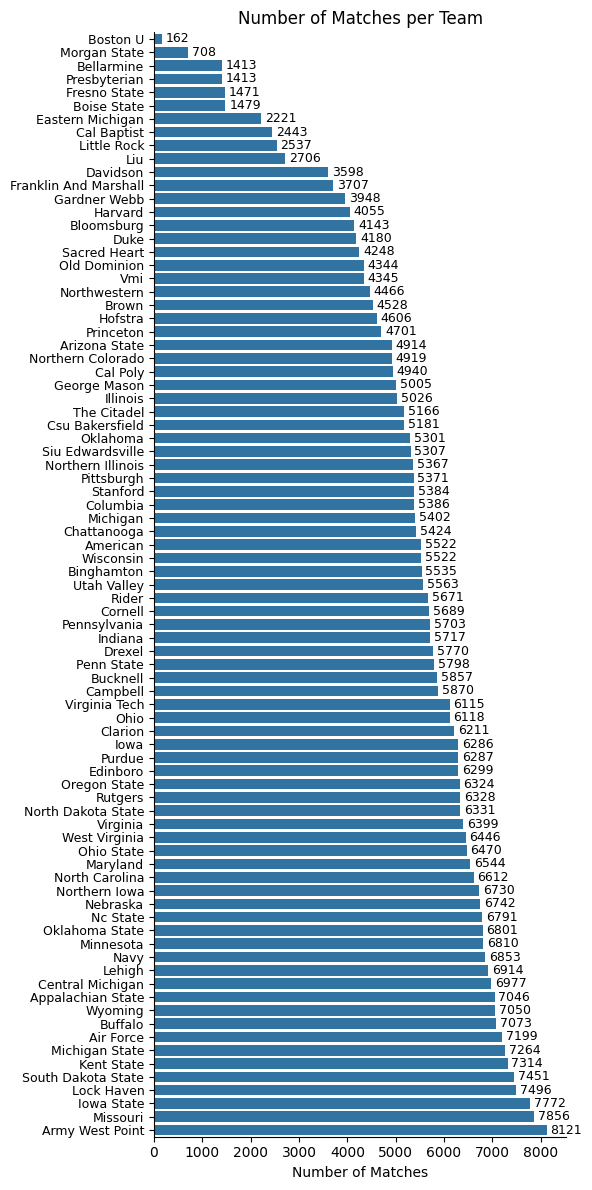

In [156]:
# Plotting the number of matches per team
plt.figure(figsize=(6, 12))
g = sns.barplot(x=team_counts_sorted, y=team_counts_sorted.index.str.title())

# Add counts on top of each bar
for p in g.patches:
    width = p.get_width()
    g.text(
        x=width + 80,
        y=p.get_y() + p.get_height() / 2, 
        s=f'{width:.0f}',
        va='center',
        fontsize=9
    )

plt.yticks(fontsize=9)
label_and_despine('Number of Matches per Team', xlabel='Number of Matches')
plt.tight_layout()

This is quite an interesting result. It turns out that the historically better teams don't have more matches than worse teams. I suppose dual meet schedule plays more of a role than tournament success, which does make sense since each additional dual meet is a guaranteed number of matches. Understandably, the teams with the fewest matches are those that were not in Division 1 for the entirety of the time period such as Presbytarian and Morgan State.

I also am interested by how often matches end with bonus points (match decided by major decision, technical fall, or fall).

In [157]:
# Creating new column to track whether match resulted in bonus points
recategorized.loc[:,'is_bonus'] = recategorized['result_type'].isin(['MD', 'TF', 'FALL'])

C:\Users\kikip\AppData\Local\Temp\ipykernel_57848\869799649.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Non-Bonus', 'Bonus'])


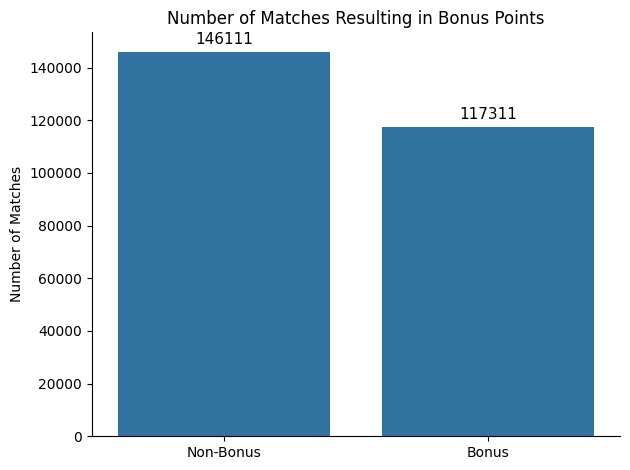

In [158]:
g = sns.countplot(data=recategorized, x='is_bonus')

# Add counts on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 3000,
        s=f'{height:.0f}',
        ha='center',
        fontsize=11
    )

g.set_xticklabels(['Non-Bonus', 'Bonus'])
label_and_despine('Number of Matches Resulting in Bonus Points', ylabel='Number of Matches')
plt.tight_layout()


C:\Users\kikip\AppData\Local\Temp\ipykernel_57848\2823496779.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(['Non-Bonus', 'Bonus'])


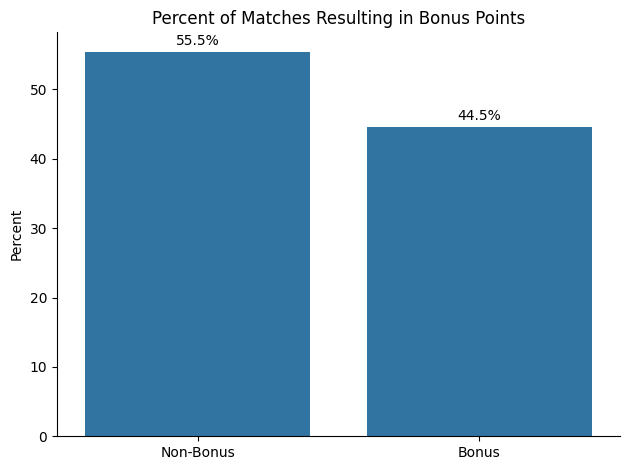

In [161]:
g = sns.countplot(data=recategorized, x='is_bonus', stat='percent')

# Add percent on top of each bar
for p in g.patches:
    height = p.get_height()
    g.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 1,
        s=f'{height:.1f}%',
        ha='center',
        fontsize=10
    )

g.set_xticklabels(['Non-Bonus', 'Bonus'])
label_and_despine('Percent of Matches Resulting in Bonus Points', ylabel='Percent')
plt.tight_layout()